In [ ]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import jax.numpy as jnp
import healpy as hp
from opt_einsum import contract

import matplotlib.pyplot as plt

import megabuster

jax.config.update("jax_enable_x64", True)


: 

# Generating input CMB and input mask

In [2]:
from fgbuster import get_observation, get_instrument

nside = 128 
npix = 12*nside**2
nstokes = 2


frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

# Get simulated map
instrument = get_instrument('SO_SAT')


np.random.seed(42)
input_freq_maps = get_observation(instrument, 'c1d0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)


0.0572967529296875

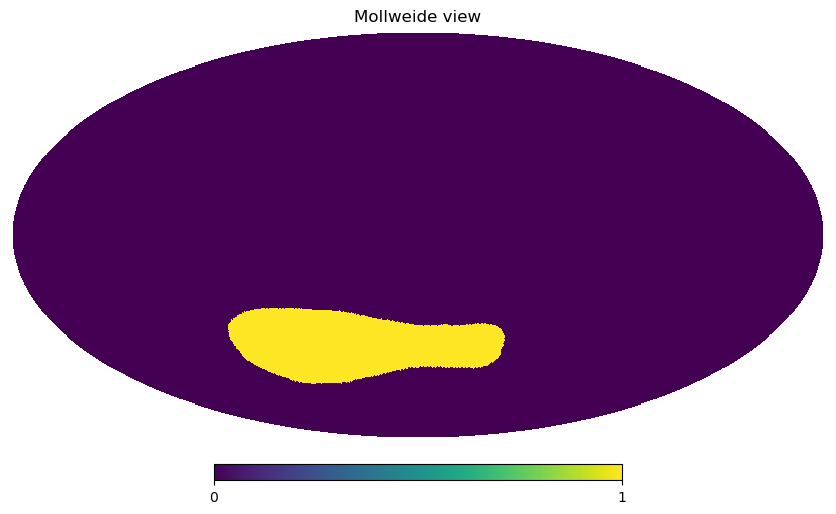

In [3]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

# path_MSS = '/lustre/fswork/projects/rech/nih/commun/megatop/MSS2/ivar/'
path_MSS = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/'
#zero_threshold = 0.1
zero_threshold = 0.45
path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0


mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0



mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

# Preparing path and loading obsmat

In [4]:
# Preparing paths

path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
path_precomputations = path_scratch
# path_precomputations = '/lustre/fswork/projects/rech/nih/commun/megatop/precomputations/'

path_N = '/pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy'

# Prepare the paths of observation matrices 

path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]


n_pix = int(mask_B_nest.sum())

In [5]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N)



Loading the inverse noise covariance matrix from /pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy


Here the full observation matrices are loaded to filter the input data

In [6]:
%%time

list_scipy_obsmat = megabuster.io.load_all_obsmat(all_path_save_obsmat_file, size_obsmat=3*npix, nstokes=3*npix, kind='precomputations_scipy', mask_stacked=None)


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_
CPU times: user 54.5 s, sys: 2min 55s, total: 3min 49s
Wall time: 3min 50s


In [7]:
%%time
indices_mask = np.arange(npix)[mask_indices]

# Retrieve mask indices for Q and U (omitting T)
mask_stacked = np.hstack((indices_mask + npix, indices_mask + 2*npix))

list_scipy_obsmat_masked = megabuster.io.load_all_obsmat(all_path_save_obsmat_file, size_obsmat=3*npix, nstokes=3*npix, kind='precomputations_scipy', mask_stacked=mask_stacked)


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_
CPU times: user 38.8 s, sys: 1min 23s, total: 2min 2s
Wall time: 2min 3s


In [8]:
%%time
freq_maps_preprocessed_QU_masked_with_leakage = np.zeros((n_freq, 3, npix))
freq_maps_preprocessed_QU_masked = np.zeros((n_freq, 3, npix))

for i in range(n_freq):
    print(i)
    freq_maps_preprocessed_QU_masked_with_leakage[i,...] = hp.reorder(
        list_scipy_obsmat[i].dot(
            hp.reorder(
                input_freq_maps[i,...],r2n=True).ravel()
            ).reshape(input_freq_maps[i,...].shape), n2r=True)


    filtered_maps = list_scipy_obsmat_masked[i].dot(
            hp.reorder(
                    input_freq_maps[i,1:,...],r2n=True
                )[...,mask_B_nest!=0].ravel()
            ).reshape((2,n_pix))    
    filtered_maps_extended = np.zeros((3, npix))
    filtered_maps_extended[1:,mask_B_nest!=0] = filtered_maps
    freq_maps_preprocessed_QU_masked[i] = hp.reorder(filtered_maps_extended, n2r=True)

freq_maps_preprocessed_QU_masked = freq_maps_preprocessed_QU_masked[:,1:,:] * mask_B_ring
freq_maps_preprocessed_QU_masked_with_leakage = freq_maps_preprocessed_QU_masked_with_leakage[:,1:,:] * mask_B_ring

0
1
2
3
4
5
CPU times: user 8.67 s, sys: 1 s, total: 9.67 s
Wall time: 9.67 s


And now we prepare the observation matrices to be used in the compsep

In [9]:
%%time
matrix_O_T = np.zeros((n_freq, nstokes, nstokes, n_pix, n_pix))

for i in range(n_freq):
    for j in range(nstokes):
        for k in range(nstokes):
            matrix_O_T[i,j,k,...] = np.array(list_scipy_obsmat_masked[i].T[j*n_pix:(j+1)*n_pix, k*n_pix:(k+1)*n_pix].todense())


CPU times: user 10.6 s, sys: 14.1 s, total: 24.7 s
Wall time: 24.7 s


In [10]:
%%time
matrix_O = np.zeros((n_freq, nstokes, nstokes, n_pix, n_pix))

for i in range(n_freq):
    for j in range(nstokes):
        for k in range(nstokes):
            matrix_O[i,j,k,...] = np.array(list_scipy_obsmat_masked[i][j*n_pix:(j+1)*n_pix, k*n_pix:(k+1)*n_pix].todense())


CPU times: user 4.97 s, sys: 15.1 s, total: 20 s
Wall time: 21.2 s


In [11]:
del list_scipy_obsmat
del list_scipy_obsmat_masked

In [12]:
matrix_O.shape

(6, 2, 2, 11265, 11265)

In [13]:
%time

new_freq_obsmat_operator_T = megabuster.tools.get_dense_furax_operator_from_freq_array(matrix_O_T)
new_freq_obsmat_operator = megabuster.tools.get_dense_furax_operator_from_freq_array(matrix_O)

CPU times: user 13 μs, sys: 10 μs, total: 23 μs
Wall time: 44.8 μs


In [14]:
%%time
all_paths_precomputations_south = [path + f'_south_f005' for i, path in enumerate(all_path_save_obsmat_file)]

freq_obsmat_operator = megabuster.io.load_all_obsmat(
    all_paths_precomputations_south, 
    size_obsmat=n_pix, 
    nstokes=2, 
    kind='precomputations_indices', 
    mask_stacked=None
)


CPU times: user 30.9 s, sys: 30 s, total: 1min
Wall time: 37.5 s


In [15]:
path_output = '/pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/'

In [16]:
%%time
array_eigvals = []
array_eigvecs = []

for idx_freq in range(n_freq):
    name_output = f'deep_south_patch_freq_{idx_freq}_eigdecomp'
    print("Loading: ", path_output+name_output+'.npz', flush=True)
    dictionary_eig = jnp.load(path_output+name_output+'.npz')

    eigvals = dictionary_eig['eigvals']
    eigvecs = dictionary_eig['eigvecs']

    print("Finishing eigenvalue decomp", flush=True)
    print('---', jnp.min(eigvals), jnp.max(eigvals), jnp.mean(eigvals), jnp.std(eigvals), flush=True)

    array_eigvecs.append([[eigvecs[i*n_pix:(i+1)*n_pix,j*n_pix:(j+1)*n_pix] for j in range(nstokes)] for i in range(nstokes)])
    array_eigvals.append(eigvals.reshape(2, n_pix))


array_eigvals = jnp.array(array_eigvals)
array_eigvecs = jnp.array(array_eigvecs)

Loading:  /pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/deep_south_patch_freq_0_eigdecomp.npz
Finishing eigenvalue decomp
--- 2.6929798289742326e-05 519.2580886820957 165.63608439553965 58.41661039880792
Loading:  /pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/deep_south_patch_freq_1_eigdecomp.npz
Finishing eigenvalue decomp
--- 7.34688524028156e-05 1230.8081982042374 447.2442093220331 158.65538309249138
Loading:  /pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/deep_south_patch_freq_2_eigdecomp.npz
Finishing eigenvalue decomp
--- 2.7961841350064405e-05 447.47618619939334 168.61462961513055 59.28606903900975
Loading:  /pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/deep_south_patch_freq_3_eigdecomp.npz
Finishing eigenvalue decomp
--- 4.888116946058838e-06 77.59697069924465 29.872822838162552 10.476669166760436
Loading:  /pscratch/sd/m/mag/fast_MSS2_obsmat/obsmat_eigvals/deep_south_patch_freq_4_eigdecomp.npz
Finishing eigenvalue decomp
--- 8.701577532652752e-07 13.99922451

In [17]:
%%time
inverse_full_matrix_central = contract('fsdqp,fdp,ftdrp->fstqr', array_eigvecs, 1/array_eigvals, array_eigvecs)

CPU times: user 105 ms, sys: 52.5 ms, total: 157 ms
Wall time: 66.7 ms


In [18]:
%%time
full_matrix_central = contract('fsdqp,fdp,ftdrp->fstqr', array_eigvecs, array_eigvals, array_eigvecs)

CPU times: user 394 μs, sys: 290 μs, total: 684 μs
Wall time: 688 μs


In [19]:
%%time

central_freq_op = megabuster.tools.get_dense_furax_operator_from_freq_array(full_matrix_central)

CPU times: user 40.2 ms, sys: 36.4 ms, total: 76.6 ms
Wall time: 39.7 ms


In [20]:
noisecov_QU_masked = N_matrix[:,1:,:] * mask_B_ring
inverse_noisecov_QU_masked = np.zeros_like(noisecov_QU_masked)
inverse_noisecov_QU_masked[noisecov_QU_masked != 0] = 1./noisecov_QU_masked[noisecov_QU_masked != 0]

inverse_noisecov_QU_masked_nested = np.zeros_like(inverse_noisecov_QU_masked)
for i in range(n_freq):
    inverse_noisecov_QU_masked_nested[i,...] = hp.reorder(inverse_noisecov_QU_masked[i], r2n=True)

inverse_noisecov_QU_masked_nested = jnp.array(inverse_noisecov_QU_masked_nested)

In [21]:
%%time
res_sanity = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        use_preconditioner_diag=True,
        use_preconditioner_pinv=False,
        matrix_precond=None,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner


2025-09-08 06:24:23.315941: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce.274 = pred[] reduce(pred[3]{0} %constant.714, pred[] %constant.606), dimensions={0}, to_apply=%and.reduce_sub_computation.6

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-09-08 06:24:23.343324: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.080137353s
Constant folding an instruction is taking > 1s:

  %reduce.274 = pred[] reduce(pred[3]{0} %constant.714, pred[] %constant.606), dimensions={0}, to_apply=%and.reduce_sub_computation.6

This isn't necessarily a bug; con

Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
{'beta_dust': Array(1.54, dtype=float64), 'beta_pl': Array(-3.00000001, dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Using diagonal preconditioner
Converged in 2 iterations
CPU times: user 1d 18min 32s, sys: 14min 9s, total: 1d 32min 41s
Wall time: 6min 59s


In [22]:
res_sanity.x

array([ 1.54      , -3.00000001])

In [23]:
%%time
res_sanity = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.55), 'beta_pl': np.array(-3.1)},
        fixed_params={'temp_dust': 20.0},
        sky_map=input_freq_maps[:,1:,:] * mask_B_ring,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        use_preconditioner_diag=True,
        use_preconditioner_pinv=False,
        matrix_precond=None,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-4},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-5},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
{'beta_dust': Array(1.54, dtype=float64), 'beta_pl': Array(-3., dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Using diagonal preconditioner
Converged in 2 iterations
CPU times: user 10.2 s, sys: 348 ms, total: 10.6 s
Wall time: 6.18 s


In [24]:
res_sanity.x

array([ 1.54, -3.  ])

In [25]:
%%time
res_0 = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        use_preconditioner_diag=True,
        use_preconditioner_pinv=False,
        matrix_precond=None,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
{'beta_dust': Array(1.53402379, dtype=float64), 'beta_pl': Array(-3.0139581, dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Using diagonal preconditioner
Converged in 2 iterations
CPU times: user 8.36 s, sys: 275 ms, total: 8.63 s
Wall time: 4.69 s


In [26]:
res_0.x

array([ 1.53402379, -3.0139581 ])

In [27]:
%%time
res_0b = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked_with_leakage,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=None,
        use_preconditioner_diag=True,
        use_preconditioner_pinv=False,
        matrix_precond=None,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Using diagonal preconditioner
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
Converged in 2 iterations
{'beta_dust': Array(1.53295336, dtype=float64), 'beta_pl': Array(-3.01610387, dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Using diagonal preconditioner
Converged in 2 iterations
CPU times: user 8.07 s, sys: 307 ms, total: 8.38 s
Wall time: 5.32 s


In [28]:
res_0b.x

array([ 1.53295336, -3.01610387])

In [29]:
%%time
res_1a = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=freq_obsmat_operator.T, #new_freq_obsmat_operator_T,
        use_preconditioner_diag=False,
        use_preconditioner_pinv=True,
        matrix_precond=inverse_full_matrix_central,
        central_freq_op=central_freq_op,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Converged in 29 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 29 iterations
{'beta_dust': Array(1.53999995, dtype=float64), 'beta_pl': Array(-2.99999921, dtype=fl

In [30]:
res_1a.x

array([ 1.53999995, -2.99999921])

In [31]:
%%time
res_1b = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked_with_leakage,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=freq_obsmat_operator.T, #new_freq_obsmat_operator_T,
        use_preconditioner_diag=False,
        use_preconditioner_pinv=True,
        matrix_precond=inverse_full_matrix_central,
        central_freq_op=central_freq_op,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Converged in 28 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 30 iterations
Converged in 28 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 28 iterations
{'beta_dust': Array(1.54007926, dtype=float64), 'beta_pl': Array(-3.0000588, dtype=float64)}
Minimization launched!! Preparing the retrieving of the maps . . .
Using p

In [32]:
res_1b.x

array([ 1.54007926, -3.0000588 ])

In [33]:
%%time
res_1c = megabuster.compsep.perform_compsep( 
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=None, 
        obsmat_operator_rhs=new_freq_obsmat_operator_T,
        use_preconditioner_diag=False,
        use_preconditioner_pinv=True,
        matrix_precond=inverse_full_matrix_central,
        central_freq_op=central_freq_op,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
{'beta_dust': Array(1.54000006, dtype=float64), 'beta_pl': Array(-2.99999966, dtype=float64)}
Minimization launch

In [34]:
res_1c.x

array([ 1.54000006, -2.99999966])

In [35]:
%%time
res_1d = megabuster.compsep.perform_compsep(
        first_guess_params={'beta_dust': np.array(1.54), 'beta_pl': np.array(-3.0)},
        fixed_params={'temp_dust': 20.0},
        sky_map=freq_maps_preprocessed_QU_masked,
        frequencies=frequencies,
        invN_matrix=inverse_noisecov_QU_masked,
        do_minimization=True,
        binary_mask=mask_B_ring,
        obs_mat_operator=freq_obsmat_operator, 
        obsmat_operator_rhs=freq_obsmat_operator.T,
        use_preconditioner_diag=False,
        use_preconditioner_pinv=True,
        matrix_precond=inverse_full_matrix_central,
        central_freq_op=None,
        dictionary_parameters_minimization={'max_iter':20, 'tol':1e-5},
        dictionary_parameters_CG={'max_steps_CG':200, 'tol_CG':1e-6},
        ordering_parameter=['beta_dust', 'beta_pl'], 
        ordering_component=['cmb', 'dust', 'synchrotron'],
    )

Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Using pseudo-inverse preconditioner
Converged in 30 iterations
Converged in 28 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 30 iterations
Converged in 30 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 30 iterations
{'beta_dust': Array(1.53999996, dtype=float64), 'beta_pl': Array(-2.9999996, dtype=float64)}
Minimization launche

In [36]:
res_1d.x

array([ 1.53999996, -2.9999996 ])

In [37]:
final_map = res_1a.s

In [38]:
final_map_with_leakage = res_1b.s

In [39]:
final_map.shape

(3, 2, 196608)

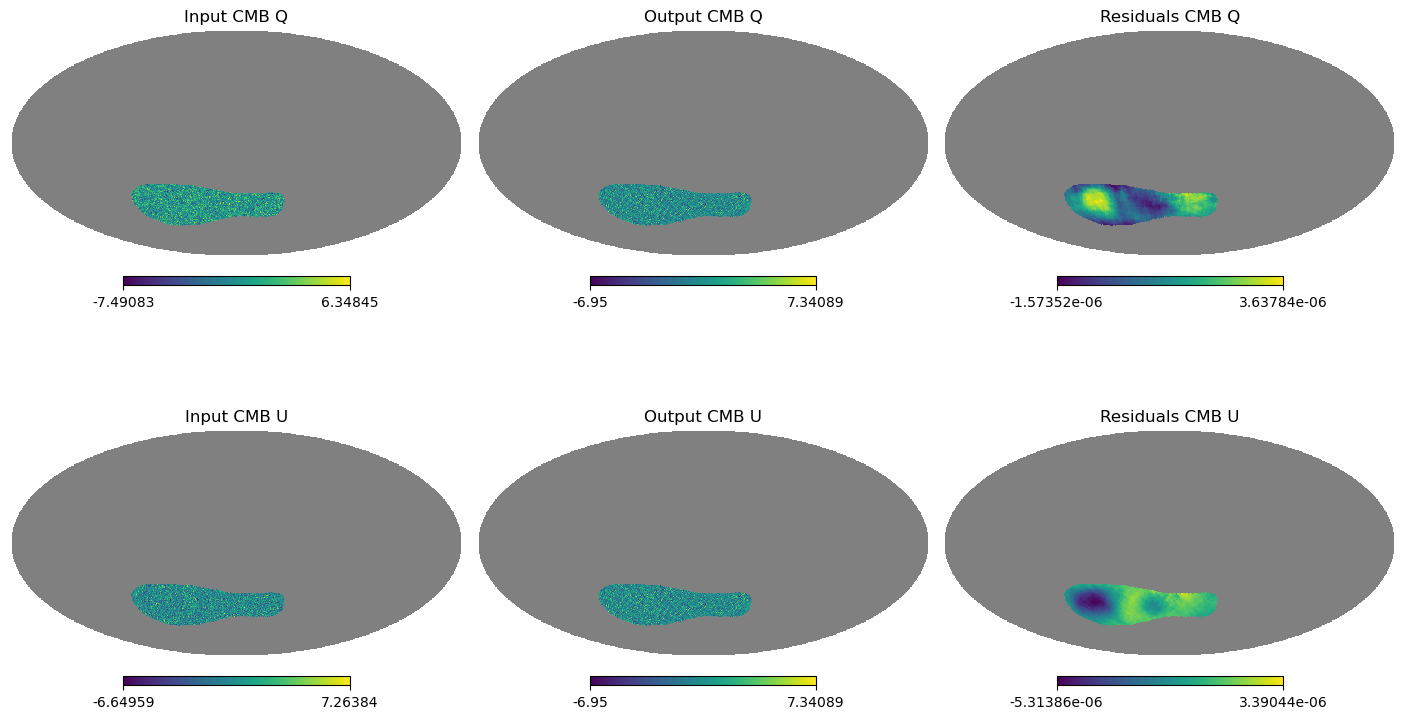

In [40]:
extended_map = np.ones((nstokes, npix))*hp.UNSEEN

plt.figure(figsize=(14,8))

ncol = 3

label_stokes = ['Q', 'U']

extended_map[:, mask_indices] = input_cmb[0,1:,mask_indices].T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol), title=f'Input CMB {label_stokes[i]}', nest=True)

#extended_map[:, mask_indices] = final_map[0,:,:]

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = final_map[0,i,mask_B_ring!=0]
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 1), title=f'Output CMB {label_stokes[i]}') #, nest=True)

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = (input_cmb[0,1:,mask_B_ring!=0] - final_map[0,:,mask_B_ring!=0]).T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 2), title=f'Residuals CMB {label_stokes[i]}') #, nest=True)


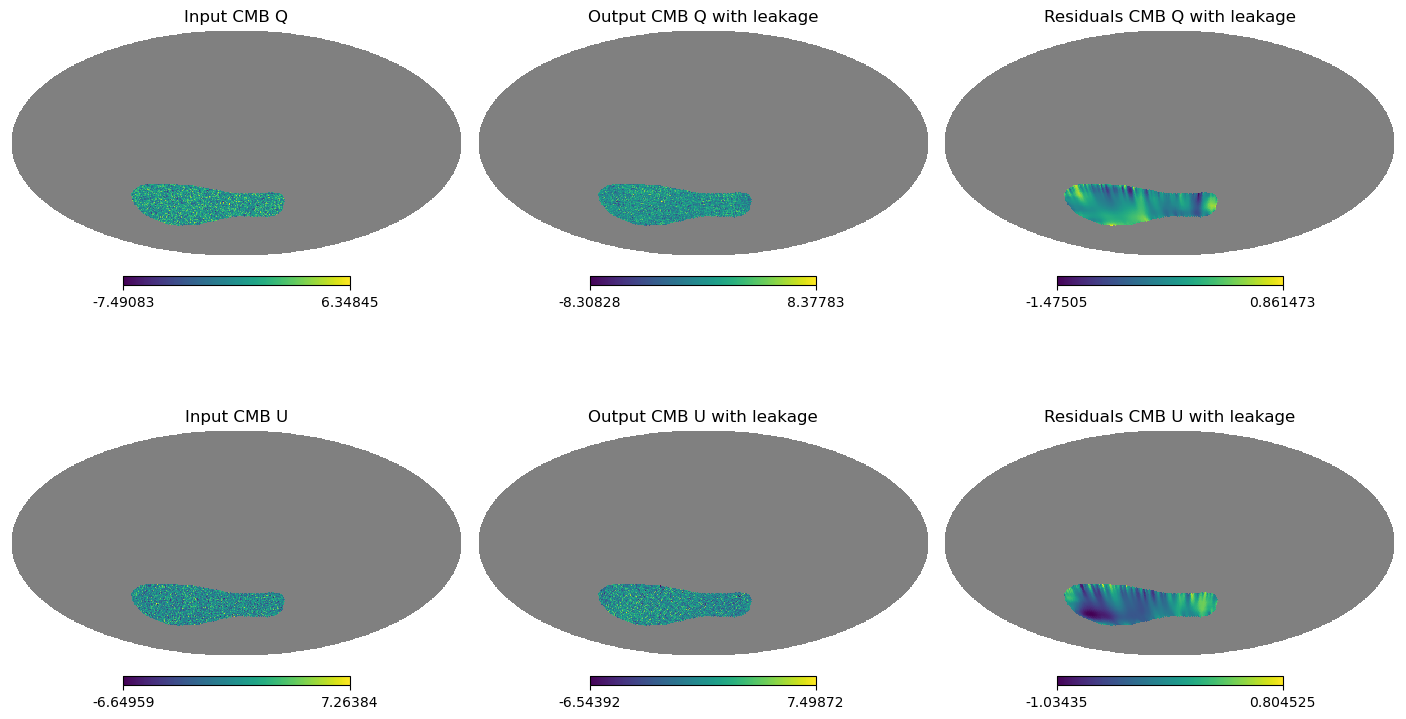

In [41]:
extended_map = np.ones((nstokes, npix))*hp.UNSEEN

plt.figure(figsize=(14,8))

ncol = 3

label_stokes = ['Q', 'U']

extended_map[:, mask_indices] = input_cmb[0,1:,mask_indices].T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol), title=f'Input CMB {label_stokes[i]}', nest=True)

#extended_map[:, mask_indices] = final_map[0,:,:]

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = final_map_with_leakage[0,...,mask_B_ring!=0].T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 1), title=f'Output CMB {label_stokes[i]} with leakage') #, nest=True)

extended_map = np.ones((nstokes, npix))*hp.UNSEEN
extended_map[:, mask_B_ring!=0] = (input_cmb[0,1:,mask_B_ring!=0] - final_map_with_leakage[0,:,mask_B_ring!=0]).T
for i in range(nstokes):
    hp.mollview(extended_map[i], sub=(2, ncol, 1 + i*ncol + 2), title=f'Residuals CMB {label_stokes[i]} with leakage') #, nest=True)


In [42]:
extended_map_input_nested = np.zeros((3, npix))
extended_map_input_nested[1:, mask_indices] = hp.reorder(input_cmb[0,1:],r2n=True)[...,mask_indices]

extended_map_output = np.zeros((3, npix))
extended_map_output[1:, mask_B_ring!=0] = final_map[0,:,mask_B_ring!=0].T

extended_map_output_with_leakage = np.zeros((3, npix))
extended_map_output_with_leakage[1:, mask_B_ring!=0] = final_map_with_leakage[0,:,mask_B_ring!=0].T

extended_map_input = hp.reorder(extended_map_input_nested, n2r=True)
#extended_map_output = hp.reorder(extended_map_output_nested, n2r=True)


In [43]:
lmax = 2*nside

In [44]:
c_ell_input = hp.anafast(extended_map_input, lmax=lmax)
c_ell_output = hp.anafast(extended_map_output, lmax=lmax)#/f_sky
c_ell_output_with_leakage = hp.anafast(extended_map_output_with_leakage, lmax=lmax)#/f_sky

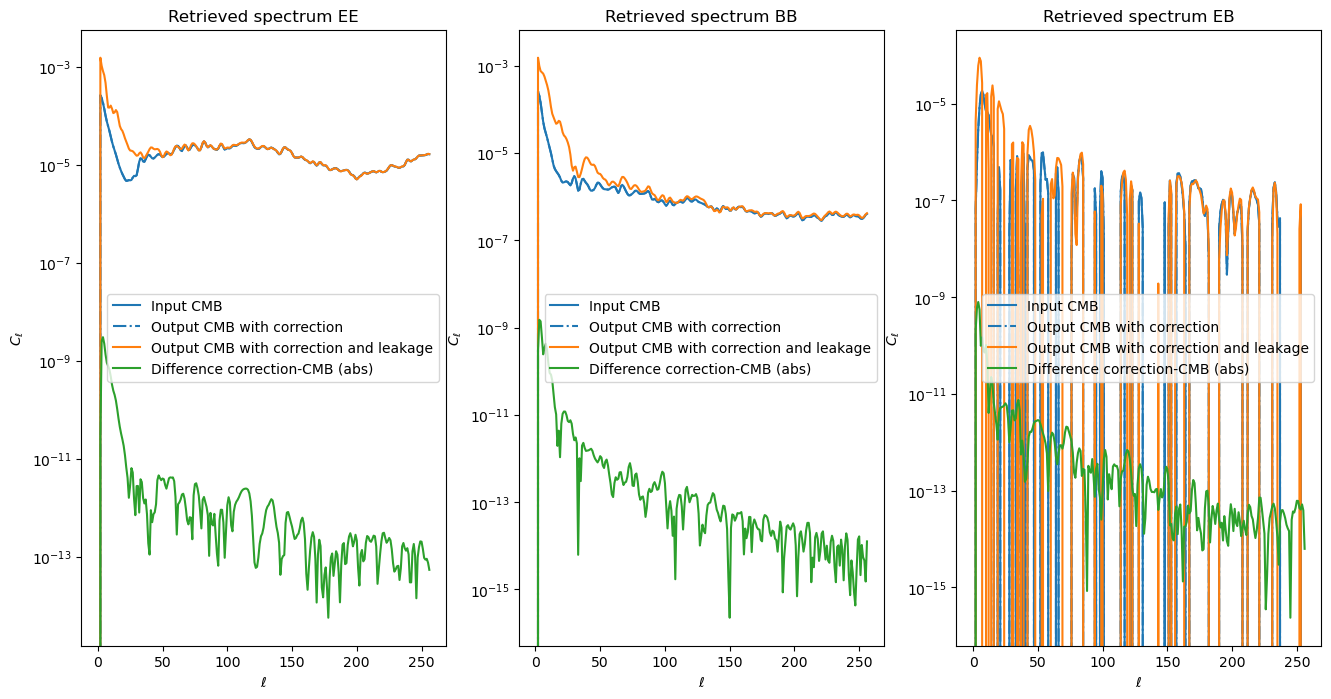

In [45]:
correl_list = ['TT', 'EE', 'BB', 'TE', 'EB', 'TB']

plt.figure(figsize=(16,8))
for k, i in enumerate([1,2,4]):
    plt.subplot(131+k)
    plt.plot(c_ell_input[i], label='Input CMB', color='tab:blue')
    plt.plot(c_ell_output[i], '-.', label='Output CMB with correction')
    plt.plot(c_ell_output_with_leakage[i], label='Output CMB with correction and leakage')
    plt.plot(np.abs(c_ell_input[i]-c_ell_output[i]), label='Difference correction-CMB (abs)')
    plt.yscale('log')
    plt.title(f"Retrieved spectrum {correl_list[i]}")
    plt.xlabel(r"$\ell$")
    plt.ylabel(r"$C_\ell$")
    plt.legend()
plt.show()